# Lab 9 Report:

# Facial Recognition
### Final Project Codebase
#### Javier Guapilla Diaz & McKinley Nhi Seecof Quevedo

--------------------

## Imports

These are the imports used to run our code. Note that we had a GPU available to us, therefore we used CUDA.

In [56]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import os
from PIL import Image # For easy manipulation of images and stuff
from PIL import ImageEnhance
import random
from sklearn.model_selection import train_test_split
d = torch.device('cuda')

## Prepare Data

Loading In Data

Due to the lack of uniformity in the data (emotion representation), we chose to join test data and train data, then shuffle and resplit evenly with proportional representation of data. This was done in an attempt to proportionally represent each emotion class in the data.

We then split the "big data" into test ($20\%$) and train ($80\%$), and took ($10\%$) of train for a validation set. Giving use the following subsets: $\mathcal{D}_{train}, \mathcal{D}_{test}, \mathcal{D}_{validation}$.

We also chose to manipulate our training data by adding additional permutated data with slight rotation, brightness shifts, and reflections, effectively quadrupling the size of our original $\mathcal{D}_{train}$.

In [57]:
folders = ["train", "test"]
emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
path = r"C:\Users\jguap\OneDrive\Desktop\spr26\final_data\data\\"
# path = r"C:\Users\AlpacaAdmin\Documents\UW\Spring26\final-proj\phys417final\FER-2013" MCKINLEY PATH
IMG_SIZE = (48, 48)

all_data = []
all_labels = []

# loading data
for f in folders:
    for i in range(len(emotions)):
        e = emotions[i]
        curr_path = os.path.join(path, f, e)
        for filename in os.listdir(curr_path):
            curr_image_path = os.path.join(curr_path, filename)
            curr_image = Image.open(curr_image_path).convert("L")
            curr_image = curr_image.resize(IMG_SIZE)
            all_data.append(np.array(curr_image))
            all_labels.append(i)

all_data = np.array(all_data)
all_labels = np.array(all_labels)

# step 1: train/test split (raw)
X_train_raw, test_data, y_train_raw, test_labels = train_test_split(
    all_data, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# step 2: train/val split (raw, before augmentation)
X_train_raw, X_val_raw, y_train_raw, validation_labels = train_test_split(
    X_train_raw, y_train_raw, test_size=0.1, stratify=y_train_raw, random_state=2
)

# step 3: augment only training portion
train_data = []
train_labels = []

for img, label in zip(X_train_raw, y_train_raw):
    # Loading in image
    curr_image = Image.fromarray(img)
    train_data.append(np.array(curr_image))
    train_labels.append(label)
    # adding permutations
    train_data.append(np.array(curr_image.transpose(Image.FLIP_LEFT_RIGHT)))
    train_labels.append(label)
    angle = random.uniform(-10, 10)
    train_data.append(np.array(curr_image.rotate(angle)))
    train_labels.append(label)
    factor = random.uniform(0.8, 1.2)
    train_data.append(np.array(ImageEnhance.Brightness(curr_image).enhance(factor)))
    train_labels.append(label)

train_data = np.array(train_data)
train_labels = np.array(train_labels)
validation_data = X_val_raw  # no augmentation

train_total = len(train_data)

In [58]:
print(train_data.shape)
print(test_data.shape)
print(validation_data.shape)

(103352, 48, 48)
(7178, 48, 48)
(2871, 48, 48)


Reshaping

In [59]:
train_data = np.reshape(train_data, (train_total, (48*48)))# YOUR CODE HERE
test_data = np.reshape(test_data, (len(test_data), (48*48)))# YOUR CODE HERE
validation_data = np.reshape(validation_data, (len(validation_data), 48*48))

Scaling

We then scaled our images, taking into account that they are already $[0,255]$, performing a simple transformation taking our images from $[0,255] \rightarrow [0, 1]$.

In [60]:
train_data = train_data.astype(np.float32) / 255.0
validation_data = validation_data.astype(np.float32) / 255.0
test_data = test_data.astype(np.float32) / 255.0

In [61]:
# Reshape train/validation/test sets to conform to PyTorch's (N, Channels, Height, Width) standard for CNNs

train_features = train_data.reshape(-1, 1, 48, 48) # Going back to 48X48 images for CNN
validation_features = validation_data.reshape(-1, 1, 48, 48) # ^^
test_features = test_data.reshape(-1,1,48,48) # ^^

# Checking the shape
print(train_features.shape)
print(validation_features.shape)
print(test_features.shape)

(103352, 1, 48, 48)
(2871, 1, 48, 48)
(7178, 1, 48, 48)


Converting to Tensors

In order to work with our GPU, we transferred both $\mathcal{D}_{validation}$ and $\mathcal{D}_{test}$ to our GPU device. Note that we did NOT move our $\mathcal{D}_{train}$ as we use DataLoader which uses CPU, and instead is done later in training.

In [62]:
# Make them into tensors
train_inputs = torch.from_numpy(train_features).float() # converting to floats
train_targets = torch.from_numpy(train_labels).long() # converting to 64-bit integer

validation_inputs = torch.from_numpy(validation_features).float().to(d) # converting to floats
validation_targets = torch.from_numpy(validation_labels).long().to(d) # converting to 64-bit integer

testing_inputs = torch.from_numpy(test_features).float().to(d) # converting to floats
testing_targets = torch.from_numpy(test_labels).long().to(d) # converting to 64-bit integer

# NOTE: Each of the tensors above used .to(d) which takes out tensors and puts them "in" my computers gpu
#       I did this to speed up computation and to actually use cuda.

## Define Model

In [63]:
import torch.nn.functional as F

class myCNNModel(torch.nn.Module):
    
    def __init__(self):
        
        super(myCNNModel, self).__init__()
        
        # Convolution followed by ReLU activation and a Maxpool
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=32,
                              kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution followed by ReLU activation and a Maxpool
        self.cnn2 = nn.Conv2d(in_channels=32, out_channels=64, 
                              kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # added
        self.cnn3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)
        self.bn3 = nn.BatchNorm2d(128)

        # Squishing down to fully connected chunk.
        # self.fc1 = nn.Linear(128*6*6, 256)
        # self.fc2 = nn.Linear(256, 7)
        self.fc1 = nn.Linear(128*6*6, 256)
        self.fc3 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, 7)

        # Batch normalizations used:
        self.bn = nn.BatchNorm1d(256)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm1d(64)

        # dropouts
        self.dropout = nn.Dropout(0.5)
        self.dropout_conv = nn.Dropout(0.25)
    
    def forward(self, x):
        
        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.maxpool1(out)
        #out = self.dropout_conv(out) # *

        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = self.dropout_conv(out) # * 

        # ^ same as before
        out = self.cnn3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)
        out = self.dropout_conv(out) # *Googled how to reduce overfitting and added this dropout

        # Flattening out our output
        out = out.view(out.size(0), -1)

        # Using a fully connected layer for the rest
        out = self.fc1(out)
        out = self.bn(out)
        out = F.relu(out)

        out = self.dropout(out)
        out = self.fc3(out)      # 256 -> 64
        out = self.bn4(out)      # BN on 64
        out = F.relu(out)

        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

## Define Hyperparameters

In [64]:
# Fix the random seed so that model performance is reproducible
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader #added dataloader so that random data is batched
torch.manual_seed(55)

# Initializing model
model = myCNNModel()
model = model.to(d) # Bc I wanted to use my gpu, also "sent" model to GPU to work w/ tensors from before.

# Defining learning rate, epoch and batchsize for mini-batch gradient
learning_rate = 0.001
epochs = 25 #30 #20 #30

## Mini-batch set up, splitting up the tensors from before
batchsize = 64
# train_batches_features = torch.split(train_inputs, batchsize)
# train_batches_targets = torch.split(train_targets, batchsize)
# batch_split_num = len(train_batches_features)
train_dataset = TensorDataset(train_inputs, train_targets)
val_dataset = TensorDataset(validation_inputs, validation_targets)
# NOTE: num_workers is for threads, and pin_memory is for locking memory
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True, pin_memory=True, num_workers=2)
validation_loader = DataLoader(val_dataset,batch_size=batchsize, shuffle=False,  pin_memory=True, num_workers=2)

# Define loss function and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

model # just to check the model I am using

myCNNModel(
  (cnn1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
  (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_

## Identify Tracked Values

In [65]:
# Placeholders for training loss and validation accuracy during training
train_loss_list = []
validation_loss_list = []
validation_accuracy_list = []

## Train Model

In [66]:
import tqdm #For loading bar

# Actual training of the modeL:
for epoch in tqdm.trange(epochs):
    
    model.train() # I was told in a previous class doing this is good practice.
    e_loss = 0.0 # the average loss for this epoch bc I use mini-batch
    
    # Working w the batches
    # for k in range(batch_split_num):
    for features, targets in train_loader:
        # set up:
        # using batch k to train on
        # features_k = train_batches_features[k]
        # targets_k = train_batches_targets[k]
        features_k = features.to(d)
        targets_k = targets.to(d)

        # training
        optimizer.zero_grad()
        train_batch_outputs = model(features_k)
        loss = loss_func(train_batch_outputs, targets_k)
        e_loss += loss.item()

        # moving the optimizer along
        loss.backward()
        optimizer.step()
    
    # getting the avg loss over the batches for this epoch
    # epoch_avg_loss = e_loss / batch_split_num
    epoch_avg_loss = e_loss / len(train_loader)
    train_loss_list.append(epoch_avg_loss)

    # Compute Validation Accuracy ----------------------------------------------------------------------
    model.eval() # Once again, I was told putting the model explicitly into eval mode was good practice
    with torch.no_grad(): # Telling PyTorch we aren't passing inputs to network for training purpose
        
        validation_outputs = model(validation_inputs) # Getting validation scores
        val_loss = loss_func(validation_outputs, validation_targets)
        validation_loss_list.append(val_loss.item())

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor) # converting validation scores to labels and
                                                               # counting the # of correctly labeled samples
        
        validation_accuracy_list.append(correct.mean()) # converting # of samples correct to percentage
        scheduler.step(val_loss.item())


100%|██████████| 25/25 [11:32<00:00, 27.71s/it]


## Visualize & Evaluate Model

Validation

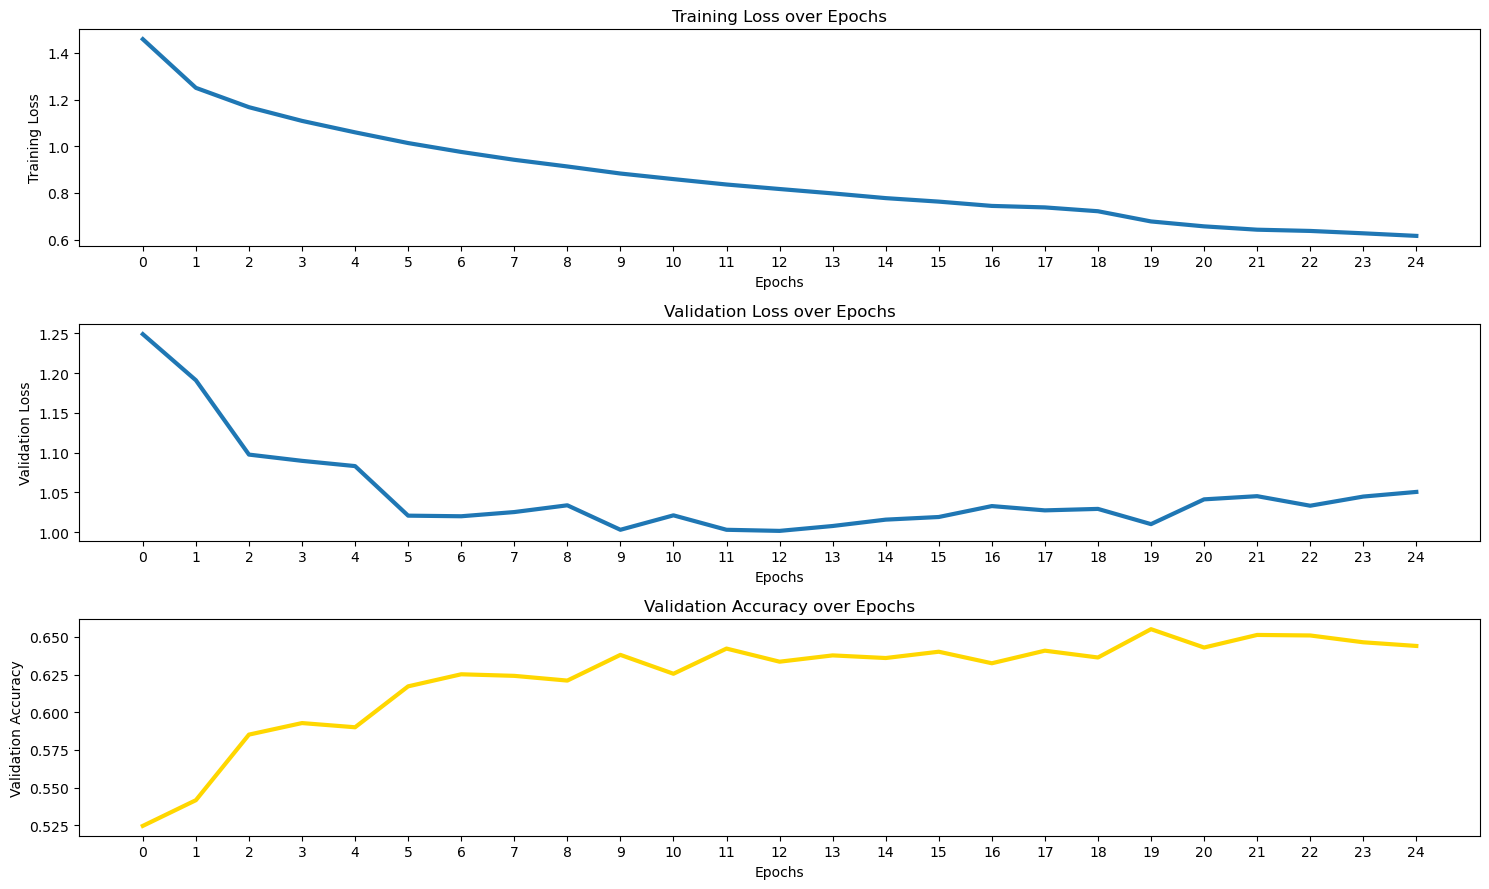

In [74]:
# Visualizing training loss and validation set accuracy
plt.figure(figsize = (15, 9))
num_to = epochs
xt = np.arange(num_to)

# Plot for Training Loss
plt.subplot(3, 1, 1)
plt.plot(train_loss_list[:num_to], linewidth = 3)
plt.title("Training Loss over Epochs")
plt.ylabel("Training Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

plt.subplot(3, 1, 2)
plt.plot(validation_loss_list[:num_to], linewidth = 3)
plt.title("Validation Loss over Epochs")
plt.ylabel("Validation Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

# Accuracy for validation set
plt.subplot(3, 1, 3)
plt.plot(validation_accuracy_list[:num_to], linewidth = 3, color = 'gold')
plt.title("Validation Accuracy over Epochs")
plt.ylabel("Validation Accuracy")
plt.xlabel("Epochs")
plt.xticks(xt)
plt.tight_layout() #googled for overlapping labels
plt.show()

In [68]:
print(train_loss_list)
print(validation_loss_list)
print(validation_accuracy_list)

[1.458802016490015, 1.2502179356551393, 1.1673307178559318, 1.1086197514652099, 1.059546524194003, 1.0136325026444237, 0.975567671573568, 0.94191760275017, 0.9133422912089817, 0.8830892797963169, 0.8591354311435215, 0.8360098418436552, 0.8166966547722417, 0.7979259142750188, 0.77767980882996, 0.7626981448093804, 0.7442713200676921, 0.7378852339720947, 0.7214552256529545, 0.6777438333713602, 0.6566877762415092, 0.6423767282128703, 0.6370535072896503, 0.6269056754215583, 0.6158479164812956]
[1.2488160133361816, 1.1909089088439941, 1.097499966621399, 1.089647650718689, 1.0830600261688232, 1.0207773447036743, 1.0200220346450806, 1.025300145149231, 1.033786654472351, 1.0030269622802734, 1.0211740732192993, 1.0030230283737183, 1.0016417503356934, 1.0077749490737915, 1.0157716274261475, 1.0190852880477905, 1.032813310623169, 1.0274189710617065, 1.0292623043060303, 1.0101362466812134, 1.0412553548812866, 1.0452618598937988, 1.033255696296692, 1.0447719097137451, 1.050595998764038]
[tensor(0.52

Test

In [72]:
# Compute the testing accuracy of all classes.
model.eval() # good practice again

print("--- Accuracy of Model ---\n")
with torch.no_grad():
    testing_inputs = testing_inputs.to(d)
    testing_targets = testing_targets.to(d)
    # testing model on test samples to get predicted values
    y_pred_test = model(testing_inputs) 
    
    # Use the same technique as above to compute the testing classification accuracy
    predicted_targets = torch.argmax(y_pred_test, dim=1)
    correct = (predicted_targets == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()*100) + '%\n') # printing the percentage

## NOTE: This is per Class VVVV

tt = testing_targets.cpu().numpy() #these are my true labels
pt = predicted_targets.cpu().numpy() # these are the predicted labels

# List of the different items we classified
c = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

print("--- Accuracy By Class ---\n")

# Looping over different classes/targets
for i in range(7):
    # Finding the accuracy:
    idx_k = np.where(tt==i) # finding true labels' indexs
    predicted_k = pt[idx_k] # using idx_k to find the predicted labels
    true_k = tt[idx_k] # getting the true labels
    percent_k = np.mean(predicted_k == true_k) # comparing true vs predicted

    # printing and formatting
    print("Accuracy of", c[i]+":", f"{percent_k*100:.2f}%")
    # ^ I used an f-string cuz it made formatting the percentage nicer

--- Accuracy of Model ---

Testing Accuracy: 64.41906%

--- Accuracy By Class ---

Accuracy of angry: 51.56%
Accuracy of disgust: 51.38%
Accuracy of fear: 40.14%
Accuracy of happy: 84.93%
Accuracy of neutral: 64.19%
Accuracy of sad: 55.26%
Accuracy of surprise: 81.38%


Printing Out Images (Actual VS Predicted)

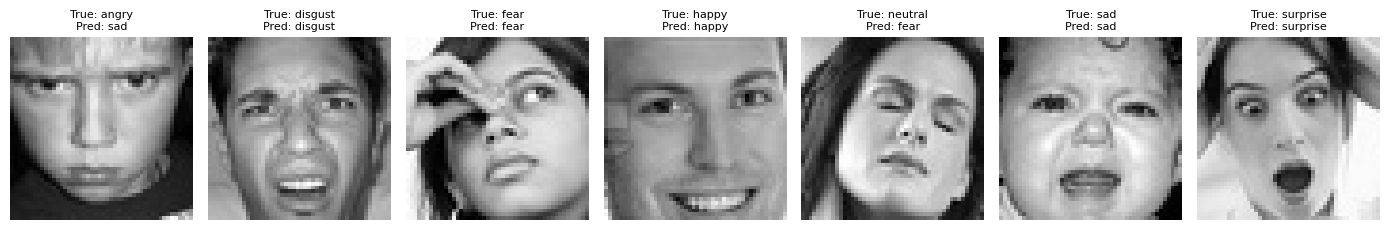

In [73]:
test_data_display = (test_features * 255.0).astype(np.uint8).reshape(-1, 48, 48)
fig, axes = plt.subplots(1, 7, figsize=(14, 3))

for i in range(7):
    idx = np.where(tt == i)[0][0]  # first instance of class i
    
    axes[i].imshow(test_data_display[idx], cmap="gray")
    axes[i].set_title(f"True: {c[tt[idx]]}\nPred: {c[pt[idx]]}", fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

NOTE: Saved model that got 65% as model2 in files.

In [71]:
# Saving the model so it can be loaded for use later
#torch.save(model.state_dict(), "model2.pth")

# LIVE COMPONENT

Here, we simply import the weights found for our best model ($65\%$)

In [ ]:
import cv2
import time
from ultralytics import YOLO
import torch.nn as nn
import torch
import torch.nn.functional as F

# --- PyTorch Model Definition ---
class FacialExpressionCNN(torch.nn.Module):
    
    def __init__(self):
        
        super(FacialExpressionCNN, self).__init__()
        
        # Convolution followed by ReLU activation and a Maxpool
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=32,
                              kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution followed by ReLU activation and a Maxpool
        self.cnn2 = nn.Conv2d(in_channels=32, out_channels=64, 
                              kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # added
        self.cnn3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)
        self.bn3 = nn.BatchNorm2d(128)

        # Squishing down to fully connected chunk.
        # self.fc1 = nn.Linear(128*6*6, 256)
        # self.fc2 = nn.Linear(256, 7)
        self.fc1 = nn.Linear(128*6*6, 256)
        self.fc3 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, 7)

        # Batch normalizations used:
        self.bn = nn.BatchNorm1d(256)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm1d(64)

        # dropouts
        self.dropout = nn.Dropout(0.5)
        self.dropout_conv = nn.Dropout(0.25)
    
    def forward(self, x):
        
        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.maxpool1(out)
        #out = self.dropout_conv(out) # *

        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = self.dropout_conv(out) # * 

        # ^ same as before
        out = self.cnn3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)
        out = self.dropout_conv(out) # *Googled how to reduce overfitting and added this dropout

        # Flattening out our output
        out = out.view(out.size(0), -1)

        # Using a fully connected layer for the rest
        out = self.fc1(out)
        out = self.bn(out)
        out = F.relu(out)

        out = self.dropout(out)
        out = self.fc3(out)      # 256 -> 64
        out = self.bn4(out)      # BN on 64
        out = F.relu(out)

        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

# --- Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# SEARCHING FOR IT VVV
face_model = YOLO("yolov11n-face.pt")

emotion_model = FacialExpressionCNN().to(device)
emotion_model.load_state_dict(torch.load("model2.pth", map_location=device))
emotion_model.eval()

emotion_dict = {0: "Angry", 1: "Disgusted", 2: "Fearful", 3: "Happy", 4: "Neutral", 5: "Sad", 6: "Surprised"}

def analyze_emotions():
    cap = cv2.VideoCapture(0) 
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        results = face_model(frame)

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])  
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

                # Pre-processing (OpenCV -> PyTorch Tensor)
                face = frame[y1:y2, x1:x2]
                if face.size == 0: continue
                face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
                face_resized = cv2.resize(face_gray, (48, 48))
                
                # Convert to Tensor: (Batch, Channel, Height, Width)
                face_tensor = torch.from_numpy(face_resized).float().to(device)
                face_tensor = face_tensor.unsqueeze(0).unsqueeze(0) / 255.0

                # Prediction
                with torch.no_grad():
                    output = emotion_model(face_tensor)
                    prob = F.softmax(output, dim=1)
                    confidence, pred_idx = torch.max(prob, 1)
                    
                    max_val = pred_idx.item()
                    emotion = emotion_dict[max_val]
                    conf_val = confidence.item()



                cv2.putText(frame, f"{emotion} ({conf_val:.2f})", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        cv2.imshow("PyTorch Emotion Monitor", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"): break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    analyze_emotions()